# 🌾 KrushiMitra - Crop Yield Prediction System

## Objective
The objective of this project is to predict crop yield using Machine Learning techniques based on agricultural parameters.

## Tech Stack
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- Streamlit

# 1. Import Libraries

In [9]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import pickle

# Plot settings
plt.style.use('ggplot')
sns.set_style('whitegrid')

In [97]:
df = pd.read_csv('../data/crop_yield.csv')

df.columns = df.columns.str.strip()

print(df.dtypes)

State             str
District          str
Crop              str
Crop_Year       int64
Season            str
Area          float64
Production    float64
Yield         float64
dtype: object


In [11]:
df

,State,District,Crop,Crop_Year,Season,Area,Production,Yield
0,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Kharif,2439.6,3415.0,1.40
1,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Rabi,1626.4,2277.0,1.40
2,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Autumn,4147.0,3060.0,0.74
3,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Summer,4147.0,2660.0,0.64
4,Andaman and Nicobar Island,NICOBARS,Arecanut,2009,Autumn,4153.0,3120.0,0.75
...,...,...,...,...,...,...,...,...
345331,West Bengal,PURULIA,Wheat,2015,Rabi,855.0,1241.0,1.45
345332,West Bengal,PURULIA,Wheat,2016,Rabi,1366.0,2415.0,1.77
345333,West Bengal,PURULIA,Wheat,2017,Rabi,1052.0,2145.0,2.04
345334,West Bengal,PURULIA,Wheat,2018,Rabi,833.0,2114.0,2.54


In [12]:
df.shape

(345336, 8)

In [13]:
df.isnull().sum()

State            0
District         0
Crop             9
Crop_Year        0
Season           0
Area             0
Production    4948
Yield            0
dtype: int64

In [16]:
for col in df.columns:

    # Agar column numeric hai
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col].fillna(df[col].median(), inplace=True)

    # Agar column categorical/string hai
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing Values Handled Successfully")

Missing Values Handled Successfully


In [19]:
df.isnull().sum()

State            0
District         0
Crop             9
Crop_Year        0
Season           0
Area             0
Production    4948
Yield            0
dtype: int64

In [18]:
df['Production'].fillna(df['Production'].median(), inplace=True)

print("Production missing values filled successfully")

Production missing values filled successfully


In [20]:
df.isnull().sum()

State            0
District         0
Crop             9
Crop_Year        0
Season           0
Area             0
Production    4948
Yield            0
dtype: int64

In [30]:
print(df['Production'].dtype)

print(df['Production'].isnull().sum())

print(df['Production'].median())
print(df['Production'].isnull().sum())

float64
0
717.0
0


In [31]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [33]:
df.drop_duplicates(inplace=True)


In [34]:
print("Updated Dataset Shape :", df.shape)

Updated Dataset Shape : (345336, 8)


In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 345336 entries, 0 to 345335
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   State       345336 non-null  str    
 1   District    345336 non-null  str    
 2   Crop        345327 non-null  str    
 3   Crop_Year   345336 non-null  int64  
 4   Season      345336 non-null  str    
 5   Area        345336 non-null  float64
 6   Production  345336 non-null  float64
 7   Yield       345336 non-null  float64
dtypes: float64(3), int64(1), str(4)
memory usage: 33.6 MB


In [36]:
df.describe()

,Crop_Year,Area,Production,Yield
count,345336.000000,3.453360e+05,3.453360e+05,345336.000000
mean,2008.887512,1.167147e+04,9.447498e+05,79.423135
std,6.564361,4.584079e+04,2.137618e+07,916.678396
min,1997.000000,4.000000e-03,0.000000e+00,0.000000
25%,2003.000000,7.400000e+01,9.000000e+01,0.550000
50%,2009.000000,5.320000e+02,7.170000e+02,1.000000
75%,2015.000000,4.112000e+03,6.940000e+03,2.470000
max,2020.000000,8.580100e+06,1.597800e+09,43958.330000


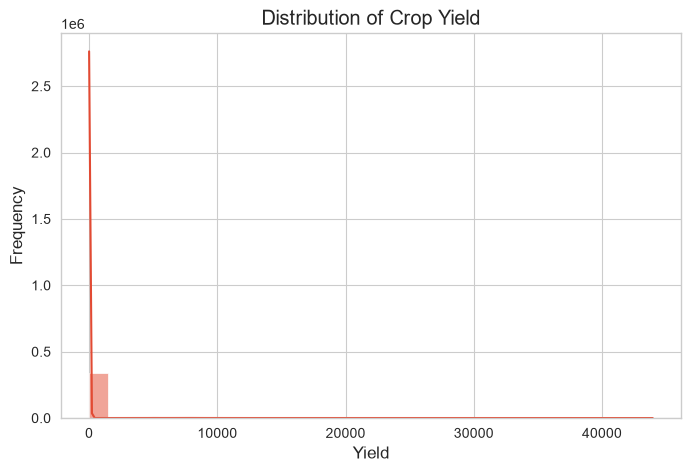

In [37]:
plt.figure(figsize=(8,5))

sns.histplot(df['Yield'], bins=30, kde=True)

plt.title('Distribution of Crop Yield')
plt.xlabel('Yield')
plt.ylabel('Frequency')

plt.show()

In [84]:
df.columns = df.columns.str.strip()

print(df.columns)

Index(['State', 'District', 'Crop', 'Crop_Year', 'Season', 'Area',
       'Production', 'Yield'],
      dtype='str')


In [98]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

categorical_cols = ['State', 'District', 'Crop', 'Season']

for col in categorical_cols:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col].astype(str))

    encoders[col] = le

print("Encoding Completed Successfully")
print(encoders.keys())

Encoding Completed Successfully
dict_keys(['State', 'District', 'Crop', 'Season'])


In [63]:
df.head()

,State,District,Crop,Crop_Year,Season,Area,Production,Yield
0,0,464,0,2007,1,2439.6,3415.0,1.40
1,0,464,0,2007,2,1626.4,2277.0,1.40
2,0,464,0,2008,0,4147.0,3060.0,0.74
3,0,464,0,2008,3,4147.0,2660.0,0.64
4,0,464,0,2009,0,4153.0,3120.0,0.75


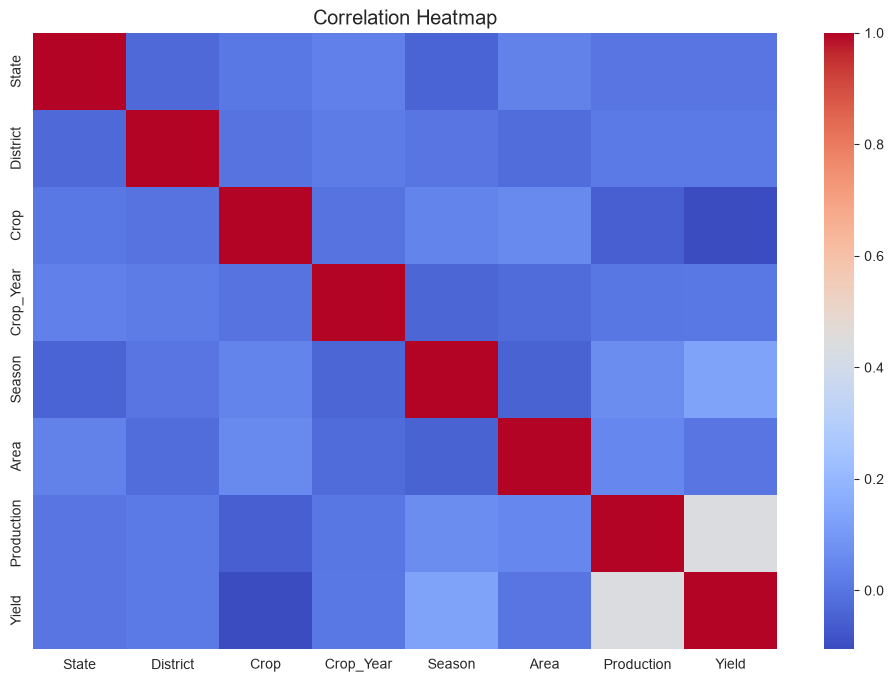

In [64]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap='coolwarm',
    annot=False
)

plt.title('Correlation Heatmap')

plt.show()

In [65]:
X = df.drop('Yield', axis=1)
y = df['Yield']

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (345336, 7)
Target Shape : (345336,)


In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape :", X_test.shape)


Training Data Shape : (276268, 7)
Testing Data Shape : (69068, 7)


In [67]:
lr = LinearRegression()

lr.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


In [68]:
dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully")


Decision Tree Model Trained Successfully


In [69]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [70]:
def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred)
    )

    r2 = r2_score(y_test, y_pred)

    return mae, rmse, r2

In [71]:
mae, rmse, r2 = evaluate_model(
    lr,
    X_test,
    y_test
)

print("Linear Regression")
print("MAE :", mae)
print("RMSE :", rmse)
print("R2 Score :", r2)

Linear Regression
MAE : 122.58890179832169
RMSE : 832.6161208638108
R2 Score : 0.1920070521503736


In [72]:
mae, rmse, r2 = evaluate_model(
    dt,
    X_test,
    y_test
)

print("Decision Tree")
print("MAE :", mae)
print("RMSE :", rmse)
print("R2 Score :", r2)

Decision Tree
MAE : 7.211488388255052
RMSE : 153.48356345492627
R2 Score : 0.9725437205069272


In [73]:
mae, rmse, r2 = evaluate_model(
    rf,
    X_test,
    y_test
)

print("Random Forest")
print("MAE :", mae)
print("RMSE :", rmse)
print("R2 Score :", r2)

Random Forest
MAE : 6.010640269396852
RMSE : 133.2571517186996
R2 Score : 0.9793034006667378


In [74]:
model_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'R2 Score': [0.1920, 0.9725, 0.9793]
})

model_results

,Model,R2 Score
0,Linear Regression,0.1920
1,Decision Tree,0.9725
2,Random Forest,0.9793


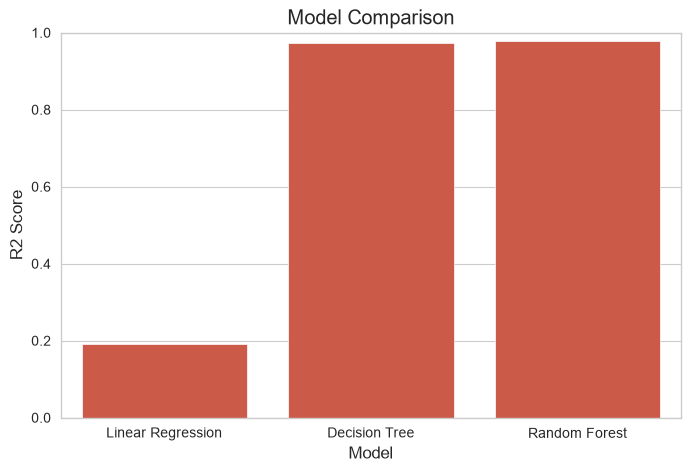

In [75]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=model_results,
    x='Model',
    y='R2 Score'
)

plt.title('Model Comparison')
plt.ylim(0, 1)

plt.show()

In [76]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
6,Production,0.593172
2,Crop,0.173636
5,Area,0.145723
0,State,0.062219
3,Crop_Year,0.015372
1,District,0.009843
4,Season,0.000034


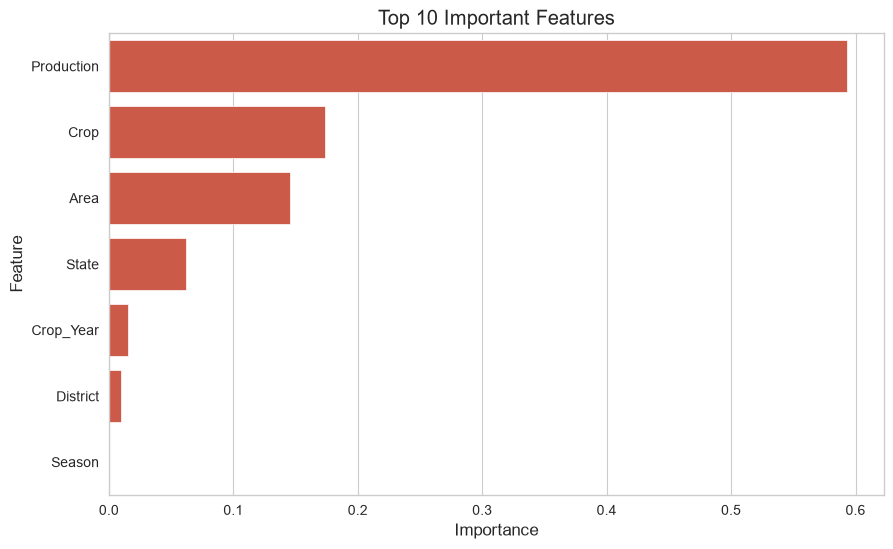

In [77]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Important Features')

plt.show()

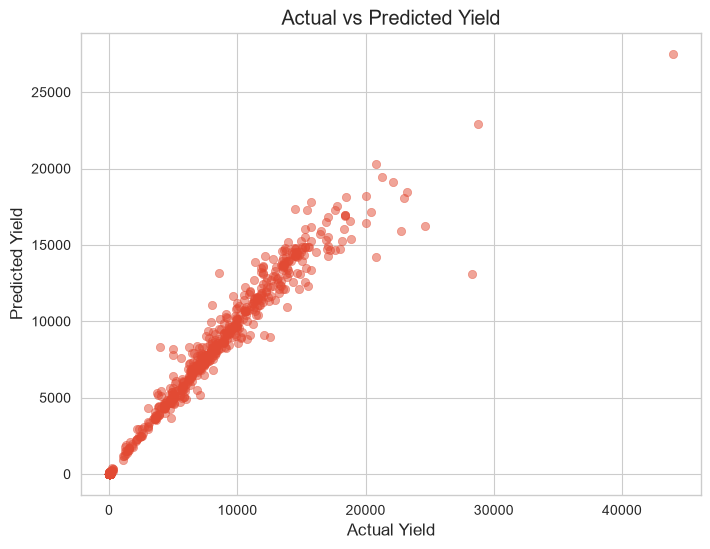

In [78]:
y_pred = rf.predict(X_test)

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield")

plt.show()

In [79]:
with open('../models/model.pkl', 'wb') as f:
    pickle.dump(rf, f)

with open('../models/encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

print("Model Saved Successfully")

Model Saved Successfully


In [80]:
import os

print(os.listdir('../models'))

['encoders.pkl', 'model.pkl']


In [99]:
import os
import pickle

# models folder create karega agar exist nahi karta
os.makedirs('../models', exist_ok=True)

# save model
with open('../models/model.pkl', 'wb') as f:
    pickle.dump(rf, f)

# save encoders
with open('../models/encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

print("Model and Encoders Saved Successfully")

Model and Encoders Saved Successfully


In [82]:
import os

print(os.listdir('../models'))

['encoders.pkl', 'model.pkl']


In [100]:
print(encoders.keys())

dict_keys(['State', 'District', 'Crop', 'Season'])


In [90]:
print(df.dtypes)

State             str
District          str
Crop              str
Crop_Year       int64
Season            str
Area          float64
Production    float64
Yield         float64
dtype: object


In [96]:
print(df.dtypes)
print("\n")

categorical_cols = df.select_dtypes(include='object').columns

print(categorical_cols)

State           int64
District        int64
Crop            int64
Crop_Year       int64
Season          int64
Area          float64
Production    float64
Yield         float64
dtype: object


Index([], dtype='str')
